## Setup and Data Loading

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve CSV path
csv_path = Path('avg_fid_summary_non_continual.csv')
if not csv_path.exists():
    raise FileNotFoundError(f"Run extract_avg_fid_non_continual.py first to generate {csv_path}")

print(f"Reading: {csv_path}")
df = pd.read_csv(csv_path)

print(f"\nDatasets: {sorted(df['dataset'].unique())}")
print(f"\nShape: {df.shape}")
df.head()

Reading: avg_fid_summary_non_continual.csv

Datasets: ['cifar10', 'fmnist', 'imagenet32', 'mnist']

Shape: (4, 6)


,dataset,avg_fid@task0,avg_fid@task1,avg_fid@task2,avg_fid@task3,avg_fid@task4
0,cifar10,36.072643,147.067947,121.148126,110.680682,115.410471
1,fmnist,17.118366,56.329803,71.755328,75.263207,103.955347
2,imagenet32,208.932602,249.113625,239.306870,260.432831,265.902499
3,mnist,13.614465,94.464859,69.426986,65.765006,102.642191


## Per-Dataset FID Plots

For each dataset, create a plot showing FID vs Task.

Saved: plots_non_continual/fid_vs_task_cifar10_non_continual.pdf


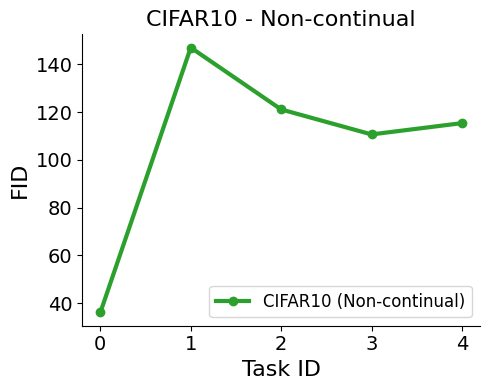

Saved: plots_non_continual/fid_vs_task_fmnist_non_continual.pdf


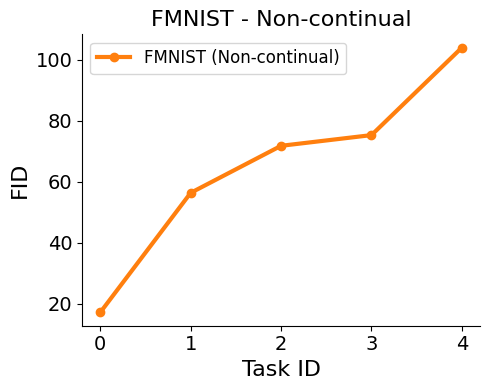

Saved: plots_non_continual/fid_vs_task_imagenet32_non_continual.pdf


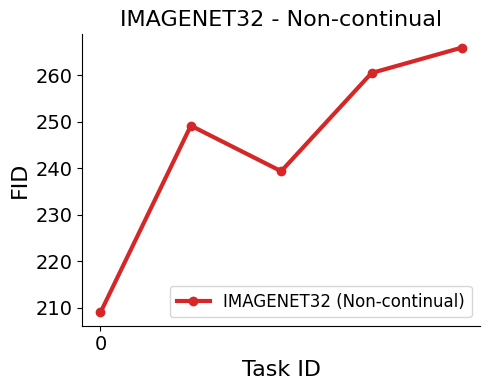

Saved: plots_non_continual/fid_vs_task_mnist_non_continual.pdf


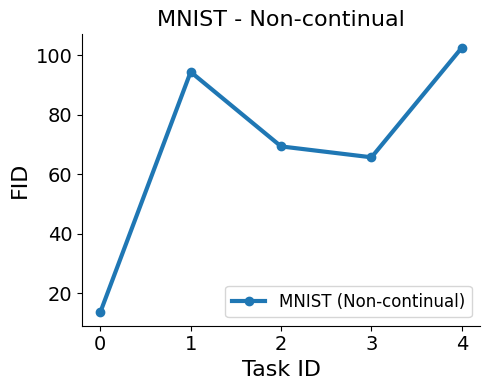

In [3]:
# Identify task columns
task_cols = [c for c in df.columns if c.startswith('avg_fid@task')]
if not task_cols:
    raise ValueError("No 'avg_fid@task*' columns found in CSV.")

col_to_id = lambda c: int(c.split('@task')[1])
task_cols = sorted(task_cols, key=col_to_id)

# Create output directory
plots_dir = Path('plots_non_continual')
plots_dir.mkdir(parents=True, exist_ok=True)

# Color mapping for different datasets
def get_color_for_dataset(dataset):
    colors = {
        'mnist': '#1f77b4',      # blue
        'fmnist': '#ff7f0e',     # orange
        'cifar10': '#2ca02c',    # green
        'imagenet32': '#d62728', # red
    }
    return colors.get(dataset.lower(), '#9467bd')

# Generate plots per dataset
for dataset in sorted(df['dataset'].unique()):
    dataset_df = df[df['dataset'] == dataset]
    
    if dataset_df.empty:
        continue
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Get values for this dataset (single row)
    row = dataset_df.iloc[0]
    values = [row[col] for col in task_cols]
    
    # Filter to tasks with data
    valid_indices = [i for i, val in enumerate(values) if not pd.isna(val)]
    if not valid_indices:
        plt.close(fig)
        continue
    
    x_ids = [col_to_id(task_cols[i]) for i in valid_indices]
    y = [values[i] for i in valid_indices]
    
    # Plot
    color = get_color_for_dataset(dataset)
    label = f"{dataset.upper()} (Non-continual)"
    ax.plot(
        x_ids,
        y,
        label=label,
        linewidth=3.0,
        linestyle='-',
        marker='o',
        color=color,
        markersize=6,
    )
    
    # Styling
    ax.set_xlabel('Task ID', fontsize=16)
    ax.set_ylabel('FID', fontsize=16)
    ax.set_title(f'{dataset.upper()} - Non-continual', fontsize=16)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # X-axis ticks
    if 'imagenet' in str(dataset).lower():
        xticks_5 = list(range(0, max(x_ids) + 1, 5))
        ax.set_xticks(xticks_5)
    else:
        ax.set_xticks(x_ids)
    
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=12, loc='best')
    
    fig.tight_layout()
    
    # Save
    out_path = plots_dir / f'fid_vs_task_{dataset}_non_continual.pdf'
    fig.savefig(out_path, dpi=200, format='pdf')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close()

## Combined Plot: All Datasets

Show all datasets on the same plot for easy comparison.

Saved: plots_non_continual/fid_vs_task_all_datasets_non_continual.pdf


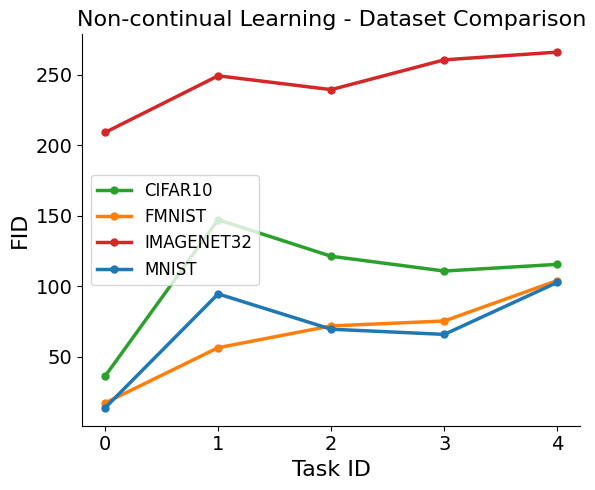

In [4]:
# Generate combined plot
fig, ax = plt.subplots(figsize=(6, 5))

any_line = False

for dataset in sorted(df['dataset'].unique()):
    dataset_df = df[df['dataset'] == dataset]
    
    if dataset_df.empty:
        continue
    
    # Get values for this dataset
    row = dataset_df.iloc[0]
    values = [row[col] for col in task_cols]
    
    valid_indices = [i for i, val in enumerate(values) if not pd.isna(val)]
    if not valid_indices:
        continue
    
    x_ids = [col_to_id(task_cols[i]) for i in valid_indices]
    y = [values[i] for i in valid_indices]
    
    # Plot
    color = get_color_for_dataset(dataset)
    label = dataset.upper()
    ax.plot(
        x_ids,
        y,
        label=label,
        linewidth=2.5,
        linestyle='-',
        marker='o',
        color=color,
        markersize=5,
    )
    any_line = True

if not any_line:
    plt.close(fig)
else:
    # Styling
    ax.set_xlabel('Task ID', fontsize=16)
    ax.set_ylabel('FID', fontsize=16)
    ax.set_title('Non-continual Learning - Dataset Comparison', fontsize=16)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=12, loc='best')
    
    fig.tight_layout()
    
    # Save
    out_path = plots_dir / 'fid_vs_task_all_datasets_non_continual.pdf'
    fig.savefig(out_path, dpi=200, format='pdf')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close()

## Final FID Table

Extract final FID values (last task) for each dataset.

In [5]:
# Locate fid_triangles directory
tri_dir = Path('fid_triangles_non_continual')
if not tri_dir.exists():
    print(f"Triangle directory not found. Run extract_fid_triangle_non_continual.py first.")
else:
    print(f"Reading triangle CSVs from: {tri_dir}")
    
    # Helper to parse dataset from filename 'dataset_non_continual.csv'
    def parse_triangle_name(path: Path):
        stem = path.stem
        parts = stem.split('_')
        if len(parts) < 1:
            return "unknown"
        return parts[0]
    
    # Compute average forgetting for a triangle CSV
    def compute_avg_forgetting(csv_path: Path):
        df = pd.read_csv(csv_path)
        if 'task_id' not in df.columns:
            return None
        fid_cols = [c for c in df.columns if c.startswith('fid-task')]
        if not fid_cols:
            return None
        
        def col_idx(c: str) -> int:
            return int(c.split('fid-task')[1])
        
        fid_cols_sorted = sorted(fid_cols, key=col_idx)
        max_task_idx = col_idx(fid_cols_sorted[-1])
        
        df_sorted = df.sort_values('task_id')
        last_row = df_sorted.iloc[-1]
        
        num = 0.0
        count = 0
        for i in range(max_task_idx + 1):
            final_val = last_row.get(f'fid-task{i}', np.nan)
            diag_row = df_sorted[df_sorted['task_id'] == i]
            diag_val = diag_row[f'fid-task{i}'].iloc[0] if not diag_row.empty else np.nan
            if not pd.isna(final_val) and not pd.isna(diag_val):
                num += float(final_val) - float(diag_val)
                count += 1
        
        if count == 0:
            return None
        return num / count
    
    # Scan all triangle CSVs
    records = []
    for csv_file in sorted(tri_dir.glob('*.csv')):
        dataset = parse_triangle_name(csv_file)
        f = compute_avg_forgetting(csv_file)
        if f is None:
            continue
        records.append({
            'dataset': dataset,
            'avg_forgetting': f"{f:.3f}",
        })
    
    if records:
        forgetting_df = pd.DataFrame.from_records(records)
        forgetting_df = forgetting_df.sort_values('dataset').reset_index(drop=True)
        
        out_csv = Path('avg_forgetting_table_non_continual.csv')
        forgetting_df.to_csv(out_csv, index=False)
        print(f"\nSaved avg forgetting summary to: {out_csv}")
        display(forgetting_df)
    else:
        print("No forgetting values computed.")

Reading triangle CSVs from: fid_triangles_non_continual

Saved avg forgetting summary to: avg_forgetting_table_non_continual.csv


,dataset,avg_forgetting
0,cifar10,72.496
1,fmnist,88.009
2,imagenet32,67.864
3,mnist,93.700


## Average Forgetting Table

Compute average forgetting from triangle CSVs for each dataset.

In [6]:
# Extract final FID values (no variance - single run per dataset)
final_fid_records = []

for dataset in df['dataset'].unique():
    dataset_df = df[df['dataset'] == dataset]
    
    if dataset_df.empty:
        continue
    
    # Get the last non-NaN value from task columns
    row = dataset_df.iloc[0]
    row_values = [row[col] for col in reversed(task_cols)]
    final_value = None
    for val in row_values:
        if not pd.isna(val):
            final_value = val
            break
    
    if final_value is not None:
        final_fid_records.append({
            'dataset': dataset,
            'final_fid': f"{final_value:.3f}"
        })

final_fid_df = pd.DataFrame(final_fid_records)
final_fid_df = final_fid_df.sort_values('dataset').reset_index(drop=True)

out_csv = Path('final_fid_table_non_continual.csv')
final_fid_df.to_csv(out_csv, index=False)
print(f"\nSaved final FID summary to: {out_csv}")
display(final_fid_df)

# Create markdown format
print("\n" + "="*80)
print("MARKDOWN FORMAT:")
print("="*80 + "\n")
print("| Dataset | Final FID |")
print("| :---: | :---: |")
for _, row in final_fid_df.iterrows():
    print(f"| {row['dataset'].upper()} | {row['final_fid']} |")


Saved final FID summary to: final_fid_table_non_continual.csv


,dataset,final_fid
0,cifar10,115.410
1,fmnist,103.955
2,imagenet32,265.902
3,mnist,102.642



MARKDOWN FORMAT:

| Dataset | Final FID |
| :---: | :---: |
| CIFAR10 | 115.410 |
| FMNIST | 103.955 |
| IMAGENET32 | 265.902 |
| MNIST | 102.642 |


In [7]:
# Load or use existing forgetting data
forgetting_csv = Path('avg_forgetting_table_non_continual.csv')
if forgetting_csv.exists():
    forgetting_df = pd.read_csv(forgetting_csv)
    
    # Merge tables
    combined_df = pd.merge(
        final_fid_df,
        forgetting_df,
        on='dataset',
        how='outer'
    )
    
    combined_df = combined_df.fillna('N/A')
    combined_df = combined_df.sort_values('dataset').reset_index(drop=True)
    
    out_csv = Path('combined_summary_non_continual.csv')
    combined_df.to_csv(out_csv, index=False)
    print(f"\nSaved combined summary to: {out_csv}")
    display(combined_df)
    
    # Create markdown format
    print("\n" + "="*80)
    print("MARKDOWN FORMAT:")
    print("="*80 + "\n")
    print("| Dataset | Final FID | Avg Forgetting |")
    print("| :---: | :---: | :---: |")
    for _, row in combined_df.iterrows():
        print(f"| {row['dataset'].upper()} | {row['final_fid']} | {row['avg_forgetting']} |")
else:
    print("Forgetting table not found. Skipping combined summary.")


Saved combined summary to: combined_summary_non_continual.csv


,dataset,final_fid,avg_forgetting
0,cifar10,115.410,72.496
1,fmnist,103.955,88.009
2,imagenet32,265.902,67.864
3,mnist,102.642,93.700



MARKDOWN FORMAT:

| Dataset | Final FID | Avg Forgetting |
| :---: | :---: | :---: |
| CIFAR10 | 115.410 | 72.496 |
| FMNIST | 103.955 | 88.009 |
| IMAGENET32 | 265.902 | 67.864 |
| MNIST | 102.642 | 93.7 |


## Combined Summary Table

Merge Final FID and Average Forgetting into a single table.